# 🏦 Analyse de Crédit en Afrique — EDA & Modélisation

**Objectif** : Prédire le défaut de crédit (`Defaut_Credit`) à partir de caractéristiques clients.

**Problématique** : Déséquilibre des classes (65% Non-Défaut vs 35% Défaut)

---

| Étape | Contenu |
|-------|--------|
| 1 | Chargement & premier aperçu |
| 2 | Analyse exploratoire (EDA) complète |
| 3 | Préparation des données |
| 4 | Baseline — sans traitement du déséquilibre |
| 5 | Traitement du déséquilibre (SMOTE, UnderSampling, class_weight) |
| 6 | Comparaison des modèles |
| 7 | Modèle final & interprétabilité |
| 8 | Conclusions |

---
## 1. Chargement & premier aperçu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

df = pd.read_excel('simulation_credit_afrique.xlsx')
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 1000 lignes × 12 colonnes


,ID_Client,Pays,Age,Genre,Statut_Professionnel,Revenu_Mensuel,Montant_Credit,Duree_Credit_Mois,Historique_Credit,Taux_Endettement,Anciennete_Bancaire_Annee,Defaut_Credit
0,AFR-0001,Côte d'Ivoire,64,M,Fonctionnaire,9400,82000,24,0,18.2,4,0
1,AFR-0002,Afrique du Sud,29,M,Salarié du Privé,55500,344000,36,0,20.1,7,0
2,AFR-0003,Nigéria,33,F,Salarié du Privé,19300,84000,24,0,65.0,14,1
3,AFR-0004,Kenya,41,M,Entrepreneur / Secteur Informel,42000,351000,48,1,78.8,12,1
4,AFR-0005,Sénégal,36,M,Salarié du Privé,15200,157000,36,2,15.5,14,0


In [2]:
print('TYPES DE DONNÉES')
print('='*50)
print(df.dtypes)
print(f'\nValeurs manquantes : {df.isnull().sum().sum()}')
print(f'Doublons           : {df.duplicated().sum()}')

TYPES DE DONNÉES
ID_Client                     object
Pays                          object
Age                            int64
Genre                         object
Statut_Professionnel          object
Revenu_Mensuel                 int64
Montant_Credit                 int64
Duree_Credit_Mois              int64
Historique_Credit              int64
Taux_Endettement             float64
Anciennete_Bancaire_Annee      int64
Defaut_Credit                  int64
dtype: object

Valeurs manquantes : 0
Doublons           : 0


In [3]:
df.describe().round(2)

,Age,Revenu_Mensuel,Montant_Credit,Duree_Credit_Mois,Historique_Credit,Taux_Endettement,Anciennete_Bancaire_Annee,Defaut_Credit
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,43.88,38709.20,291094.00,31.19,0.73,28.36,7.03,0.35
std,15.08,24558.15,229019.68,14.66,0.69,16.74,4.34,0.48
min,18.00,6400.00,32000.00,12.00,0.00,0.50,0.00,0.00
25%,31.00,21775.00,143000.00,24.00,0.00,15.30,3.00,0.00
50%,43.00,32350.00,220000.00,24.00,1.00,25.70,7.00,0.00
75%,57.00,48900.00,371250.00,36.00,1.00,39.40,11.00,1.00
max,70.00,173600.00,1969000.00,60.00,2.00,87.90,14.00,1.00


In [4]:
target_counts = df['Defaut_Credit'].value_counts()
target_pct = df['Defaut_Credit'].value_counts(normalize=True) * 100

print('Distribution de la cible :')
print(f'  0 (Non-Défaut) : {target_counts[0]:>4} ({target_pct[0]:.1f}%)')
print(f'  1 (Défaut)     : {target_counts[1]:>4} ({target_pct[1]:.1f}%)')
print(f'\n⚠️  Ratio de déséquilibre : {target_counts[0]/target_counts[1]:.2f} : 1')

Distribution de la cible :
  0 (Non-Défaut) :  653 (65.3%)
  1 (Défaut)     :  347 (34.7%)

⚠️  Ratio de déséquilibre : 1.88 : 1


---
## 2. Analyse Exploratoire (EDA)
### 2.1 Variable cible

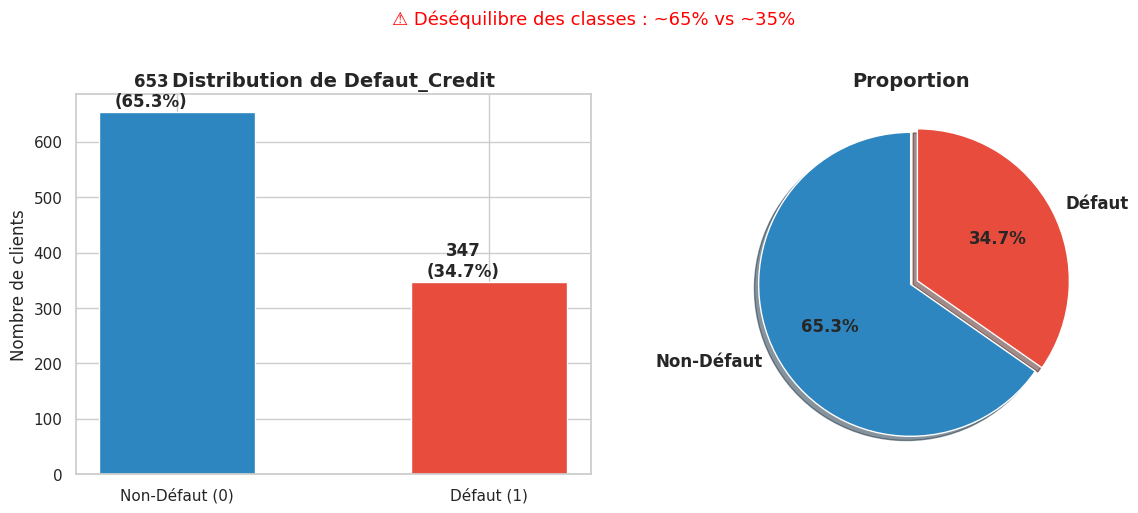

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2E86C1', '#E74C3C']

bars = axes[0].bar(['Non-Défaut (0)', 'Défaut (1)'], target_counts.values,
                    color=colors, edgecolor='white', width=0.5)
for bar, val, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/3, bar.get_height() + 10,
                 f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribution de Defaut_Credit', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Nombre de clients')

axes[1].pie(target_counts.values, labels=['Non-Défaut', 'Défaut'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            explode=(0, 0.05), shadow=True)
axes[1].set_title('Proportion', fontweight='bold', fontsize=14)

plt.suptitle('⚠️ Déséquilibre des classes : ~65% vs ~35%', fontsize=13, color='red', y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Variables catégorielles vs Défaut

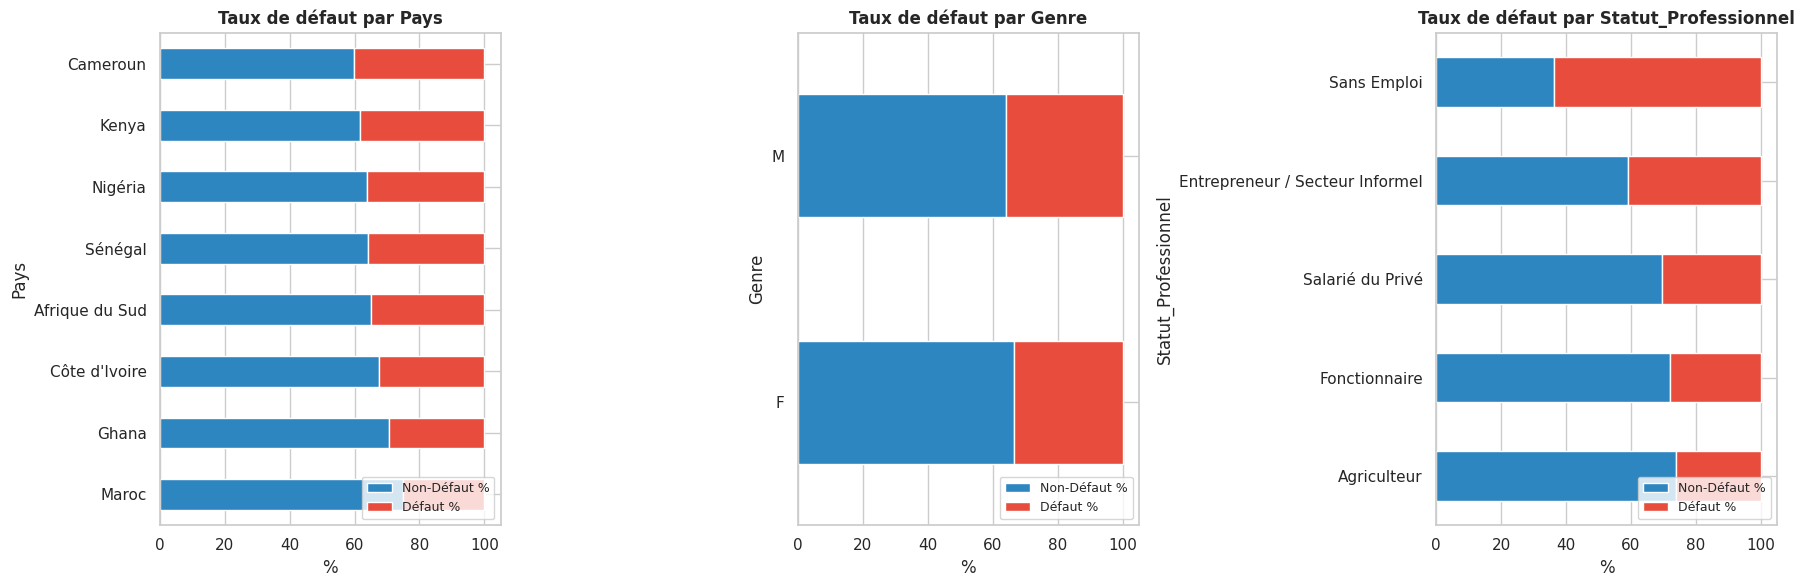

In [9]:
cat_cols = ['Pays', 'Genre', 'Statut_Professionnel']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Defaut_Credit'], normalize='index') * 100
    ct.columns = ['Non-Défaut %', 'Défaut %']
    ct = ct.sort_values('Défaut %', ascending=True)
    ct.plot(kind='barh', stacked=True, ax=axes[i], color=colors, edgecolor='white')
    axes[i].set_title(f'Taux de défaut par {col}', fontweight='bold')
    axes[i].set_xlabel('%')
    axes[i].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
from rich.console import Console
from rich.table import Table

console = Console()

for col in cat_cols:
    summary = df.groupby(col)['Defaut_Credit'].agg(['count', 'sum', 'mean'])
    summary.columns = ['Effectif', 'Nb_Défauts', 'Taux_Défaut_%']
    summary['Taux_Défaut_%'] = (summary['Taux_Défaut_%'] * 100).round(1)

    summary = summary.sort_values('Taux_Défaut_%', ascending=False)

    # Création du tableau Rich
    table = Table(title=f"Analyse par {col}")

    table.add_column(col, style="cyan", justify="left")
    table.add_column("Effectif", style="green", justify="right")
    table.add_column("Nb Défauts", style="red", justify="right")
    table.add_column("Taux Défaut (%)", style="magenta", justify="right")

    # Ajout des lignes
    for index, row in summary.iterrows():
        table.add_row(
            str(index),
            str(row['Effectif']),
            str(row['Nb_Défauts']),
            f"{row['Taux_Défaut_%']}%"
        )

    console.print(table)

                      Analyse par Pays                      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Pays           ┃ Effectif ┃ Nb Défauts ┃ Taux Défaut (%) ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Cameroun       │    137.0 │       55.0 │           40.1% │
│ Kenya          │    133.0 │       51.0 │           38.3% │
│ Nigéria        │    113.0 │       41.0 │           36.3% │
│ Sénégal        │    225.0 │       81.0 │           36.0% │
│ Afrique du Sud │     46.0 │       16.0 │           34.8% │
│ Côte d'Ivoire  │    176.0 │       57.0 │           32.4% │
│ Ghana          │     78.0 │       23.0 │           29.5% │
│ Maroc          │     92.0 │       23.0 │           25.0% │
└────────────────┴──────────┴────────────┴─────────────────┘

                 Analyse par Genre                 
┏━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Genre ┃ Effectif ┃ Nb Défauts ┃ Taux Défaut (%) ┃
┡━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ M     │    550.0 │      197.0 │           35.8% │
│ F     │    450.0 │      150.0 │           33.3% │
└───────┴──────────┴────────────┴─────────────────┘

                      Analyse par Statut_Professionnel                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Statut_Professionnel            ┃ Effectif ┃ Nb Défauts ┃ Taux Défaut (%) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Sans Emploi                     │     55.0 │       35.0 │           63.6% │
│ Entrepreneur / Secteur Informel │    314.0 │      128.0 │           40.8% │
│ Salarié du Privé                │    354.0 │      108.0 │           30.5% │
│ Fonctionnaire                   │    193.0 │       54.0 │           28.0% │
│ Agriculteur                     │     84.0 │       22.0 │           26.2% │
└─────────────────────────────────┴──────────┴────────────┴─────────────────┘

### 2.3 Distributions numériques par classe

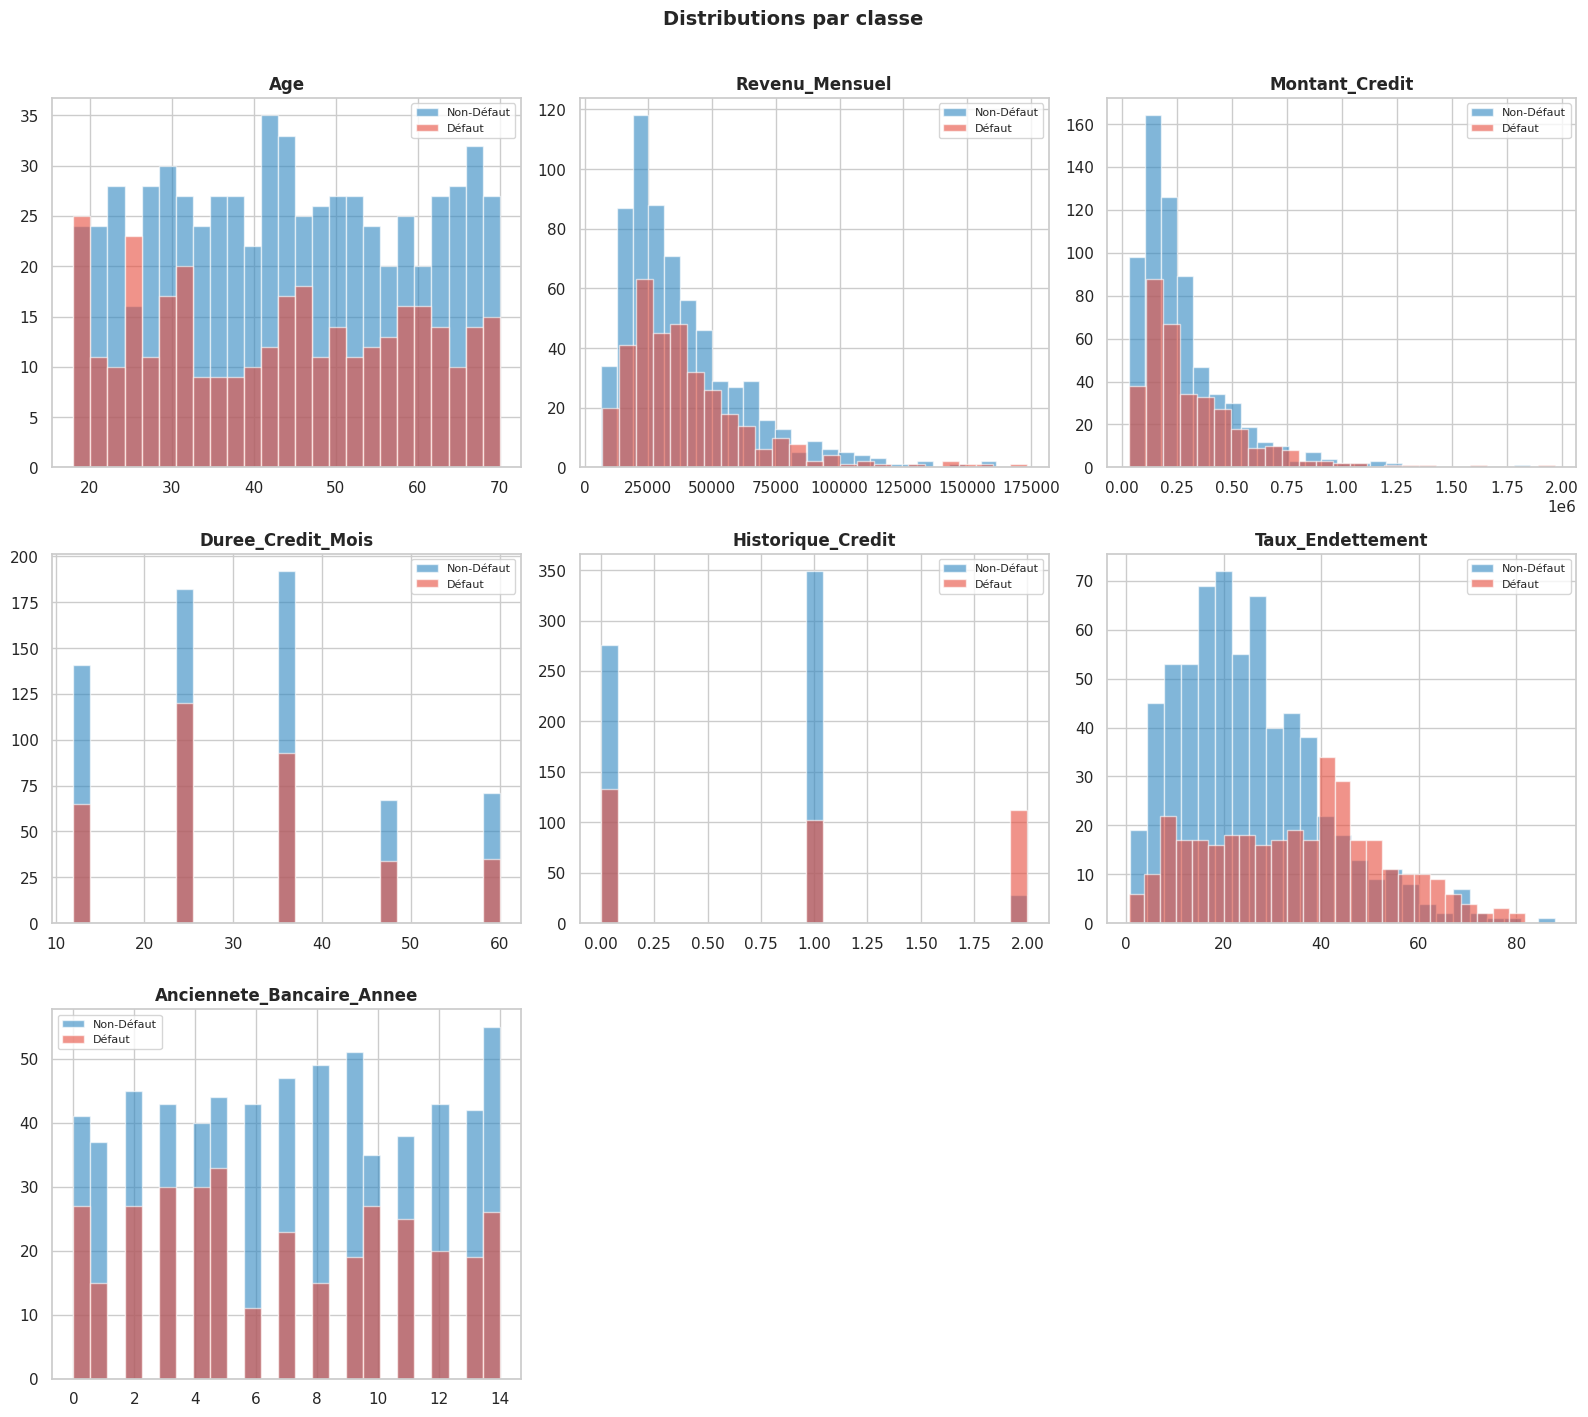

In [13]:
num_cols = ['Age', 'Revenu_Mensuel', 'Montant_Credit', 'Duree_Credit_Mois',
            'Historique_Credit', 'Taux_Endettement', 'Anciennete_Bancaire_Annee']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, color, label in [(0, '#2E86C1', 'Non-Défaut'), (1, '#E74C3C', 'Défaut')]:
        axes[i].hist(df[df['Defaut_Credit']==val][col], bins=25, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions par classe', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Boxplots

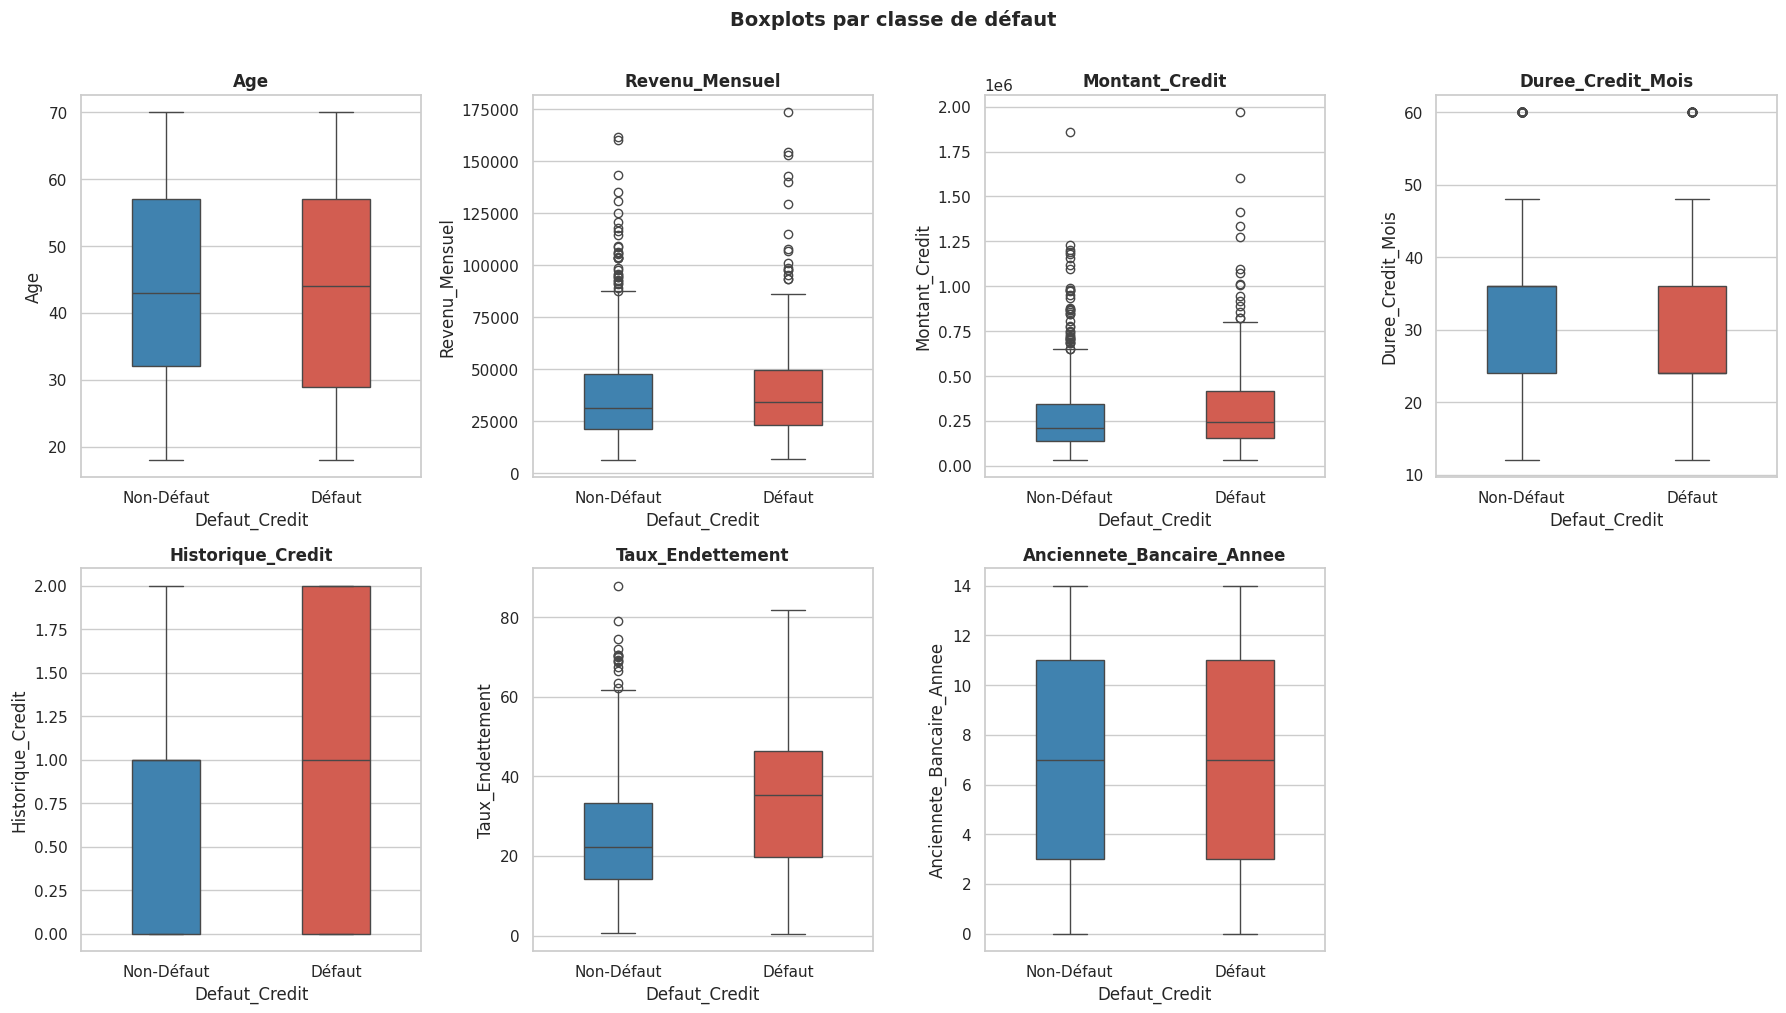

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Defaut_Credit', y=col, ax=axes[i], palette=colors, width=0.4)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Non-Défaut', 'Défaut'])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots par classe de défaut', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Matrice de corrélation

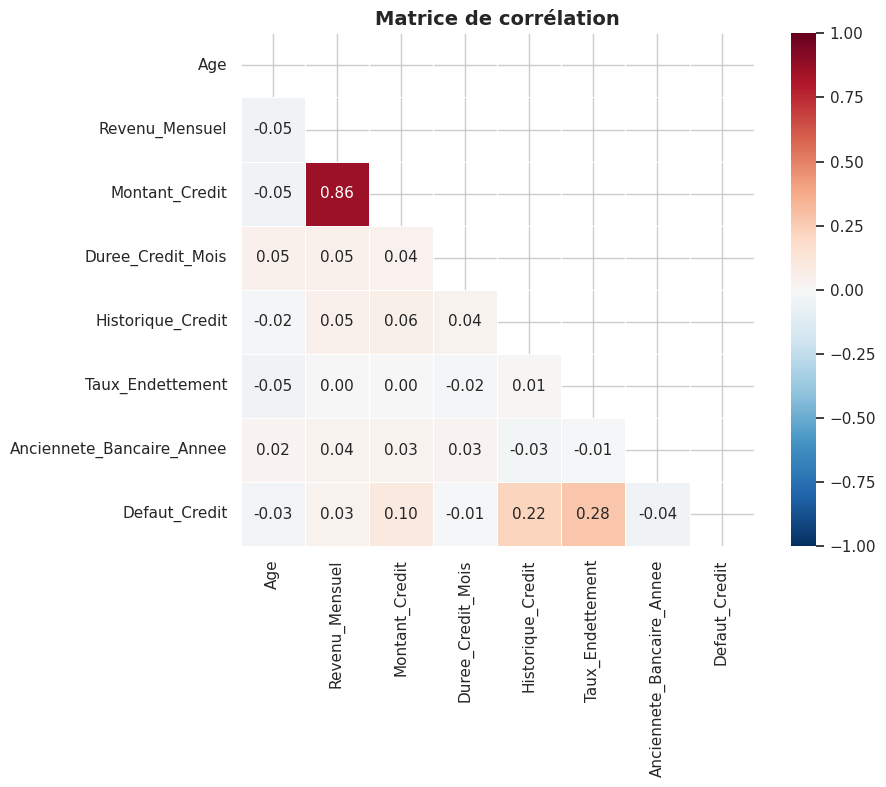


Corrélations avec Defaut_Credit :
Taux_Endettement             0.279
Historique_Credit            0.220
Montant_Credit               0.096
Revenu_Mensuel               0.035
Duree_Credit_Mois           -0.012
Age                         -0.032
Anciennete_Bancaire_Annee   -0.040


In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols + ['Defaut_Credit']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrélations avec Defaut_Credit :')
print(corr['Defaut_Credit'].drop('Defaut_Credit').sort_values(ascending=False).round(3).to_string())

### 2.6 Feature Engineering

In [16]:
df['Ratio_Credit_Revenu'] = df['Montant_Credit'] / df['Revenu_Mensuel']
df['Mensualite_Estimee'] = df['Montant_Credit'] / df['Duree_Credit_Mois']
df['Ratio_Mensualite_Revenu'] = df['Mensualite_Estimee'] / df['Revenu_Mensuel'] * 100

new_features = ['Ratio_Credit_Revenu', 'Mensualite_Estimee', 'Ratio_Mensualite_Revenu']
print('Nouvelles variables :')
for col in new_features:
    print(f'  {col} — moy: {df[col].mean():.2f}, méd: {df[col].median():.2f}')

# Corrélation des nouvelles features avec la cible
print('\nCorrélation avec Defaut_Credit :')
for col in new_features:
    print(f'  {col}: {df[col].corr(df["Defaut_Credit"]):.3f}')

Nouvelles variables :
  Ratio_Credit_Revenu — moy: 7.48, méd: 7.36
  Mensualite_Estimee — moy: 11971.66, méd: 7881.94
  Ratio_Mensualite_Revenu — moy: 31.03, méd: 24.78

Corrélation avec Defaut_Credit :
  Ratio_Credit_Revenu: 0.123
  Mensualite_Estimee: 0.042
  Ratio_Mensualite_Revenu: 0.051


---
## 3. Préparation des données

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_model = df.drop(columns=['ID_Client']).copy()

# Encodage
label_encoders = {}
cat_features = ['Pays', 'Genre', 'Statut_Professionnel']
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df_model.drop('Defaut_Credit', axis=1)
y = df_model['Defaut_Credit']

print(f'\nFeatures ({X.shape[1]}) : {list(X.columns)}')

Pays: {'Afrique du Sud': np.int64(0), 'Cameroun': np.int64(1), "Côte d'Ivoire": np.int64(2), 'Ghana': np.int64(3), 'Kenya': np.int64(4), 'Maroc': np.int64(5), 'Nigéria': np.int64(6), 'Sénégal': np.int64(7)}
Genre: {'F': np.int64(0), 'M': np.int64(1)}
Statut_Professionnel: {'Agriculteur': np.int64(0), 'Entrepreneur / Secteur Informel': np.int64(1), 'Fonctionnaire': np.int64(2), 'Salarié du Privé': np.int64(3), 'Sans Emploi': np.int64(4)}

Features (13) : ['Pays', 'Age', 'Genre', 'Statut_Professionnel', 'Revenu_Mensuel', 'Montant_Credit', 'Duree_Credit_Mois', 'Historique_Credit', 'Taux_Endettement', 'Anciennete_Bancaire_Annee', 'Ratio_Credit_Revenu', 'Mensualite_Estimee', 'Ratio_Mensualite_Revenu']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f'Train : {X_train_sc.shape[0]} lignes — {dict(y_train.value_counts())}')
print(f'Test  : {X_test_sc.shape[0]} lignes — {dict(y_test.value_counts())}')

Train : 800 lignes — {0: np.int64(522), 1: np.int64(278)}
Test  : 200 lignes — {0: np.int64(131), 1: np.int64(69)}


---
## 4. Baseline — Sans traitement du déséquilibre

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, recall_score, precision_score, accuracy_score,
    roc_curve, precision_recall_curve, average_precision_score
)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'KNN (k=7)':           KNeighborsClassifier(n_neighbors=7),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
}

baseline_results = []
for name, model in baseline_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    baseline_results.append({
        'Modèle': name, 'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
    })

df_bl = pd.DataFrame(baseline_results).set_index('Modèle').round(4)
print('── BASELINE (aucune correction du déséquilibre) ──\n')
print(df_bl.to_string())

── BASELINE (aucune correction du déséquilibre) ──

                     Accuracy  Precision  Recall      F1     AUC
Modèle                                                          
Logistic Regression     0.710     0.6279  0.3913  0.4821  0.7690
Random Forest           0.795     0.7333  0.6377  0.6822  0.8215
Gradient Boosting       0.750     0.6462  0.6087  0.6269  0.7922
KNN (k=7)               0.680     0.5758  0.2754  0.3725  0.6540
Decision Tree           0.765     0.6486  0.6957  0.6713  0.8097


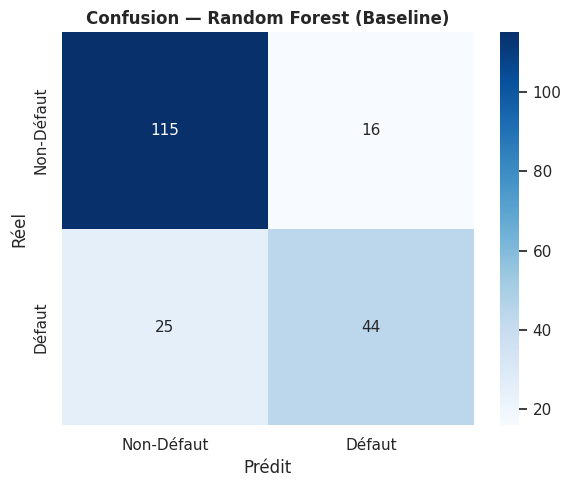


⚠️ Recall Défaut = 63.77% — des défauts passent inaperçus !


In [20]:
# Matrice de confusion du meilleur baseline
best_bl = df_bl['F1'].idxmax()
y_pred_bl = baseline_models[best_bl].predict(X_test_sc)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_bl), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Défaut', 'Défaut'], yticklabels=['Non-Défaut', 'Défaut'])
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f'Confusion — {best_bl} (Baseline)', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n⚠️ Recall Défaut = {recall_score(y_test, y_pred_bl):.2%} — des défauts passent inaperçus !')

---
## 5. Traitement du déséquilibre

### Méthodes testées :
| # | Méthode | Principe |
|---|---------|----------|
| 1 | `class_weight='balanced'` | Pénalise les erreurs sur la classe minoritaire |
| 2 | **SMOTE** (implémentation manuelle) | Crée des exemples synthétiques par interpolation KNN |
| 3 | **Random UnderSampling** | Réduit la majorité au niveau de la minorité |
| 4 | **SMOTE + UnderSampling** | Combinaison : sur-échantillonnage + nettoyage |

In [21]:
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample

# ══════════════════════════════════════════════════════════════════════════
# IMPLÉMENTATION MANUELLE DE SMOTE
# ══════════════════════════════════════════════════════════════════════════
def smote_manual(X, y, target_class=1, k_neighbors=5, random_state=42):
    """
    SMOTE : Synthetic Minority Over-sampling Technique
    Crée des échantillons synthétiques en interpolant entre les voisins
    les plus proches de la classe minoritaire.
    """
    np.random.seed(random_state)
    X_arr = X.values if hasattr(X, 'values') else np.array(X)
    y_arr = y.values if hasattr(y, 'values') else np.array(y)

    X_minority = X_arr[y_arr == target_class]
    X_majority = X_arr[y_arr != target_class]

    n_to_generate = len(X_majority) - len(X_minority)

    # Trouver les k plus proches voisins dans la classe minoritaire
    nn = NearestNeighbors(n_neighbors=k_neighbors + 1)
    nn.fit(X_minority)
    distances, indices = nn.kneighbors(X_minority)

    synthetic = []
    for _ in range(n_to_generate):
        # Choisir un point aléatoire de la minorité
        idx = np.random.randint(0, len(X_minority))
        point = X_minority[idx]
        # Choisir un voisin aléatoire (exclure le point lui-même = index 0)
        nn_idx = indices[idx][np.random.randint(1, k_neighbors + 1)]
        neighbor = X_minority[nn_idx]
        # Interpoler : nouveau_point = point + lambda * (voisin - point)
        lam = np.random.uniform(0, 1)
        new_point = point + lam * (neighbor - point)
        synthetic.append(new_point)

    X_synthetic = np.array(synthetic)
    X_resampled = np.vstack([X_arr, X_synthetic])
    y_resampled = np.hstack([y_arr, np.full(n_to_generate, target_class)])

    return pd.DataFrame(X_resampled, columns=X.columns if hasattr(X, 'columns') else None), \
           pd.Series(y_resampled)


def random_undersample(X, y, target_class=0, random_state=42):
    """Réduit la classe majoritaire au niveau de la classe minoritaire."""
    X_arr = X.values if hasattr(X, 'values') else np.array(X)
    y_arr = y.values if hasattr(y, 'values') else np.array(y)

    minority_count = (y_arr != target_class).sum()
    majority_idx = np.where(y_arr == target_class)[0]
    minority_idx = np.where(y_arr != target_class)[0]

    np.random.seed(random_state)
    sampled_majority = np.random.choice(majority_idx, size=minority_count, replace=False)

    all_idx = np.hstack([sampled_majority, minority_idx])
    np.random.shuffle(all_idx)

    cols = X.columns if hasattr(X, 'columns') else None
    return pd.DataFrame(X_arr[all_idx], columns=cols), pd.Series(y_arr[all_idx])


print('Fonctions SMOTE et UnderSampling définies')

Fonctions SMOTE et UnderSampling définies


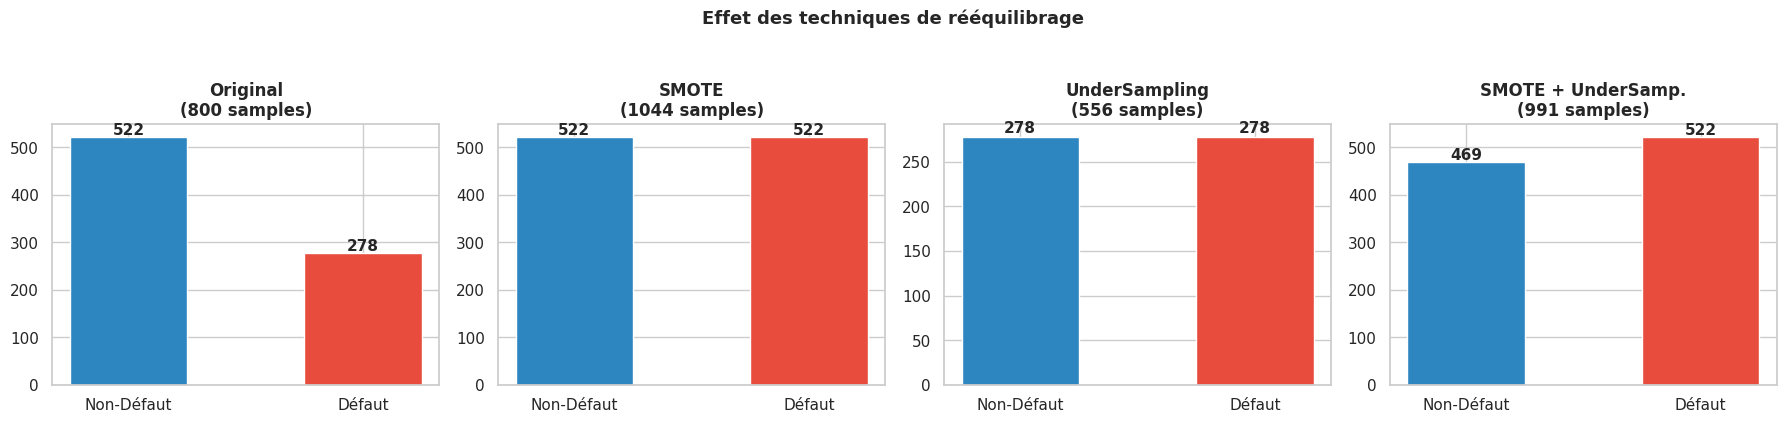

In [22]:
# ── Appliquer et visualiser ───────────────────────────────────────────────
X_smote, y_smote = smote_manual(X_train_sc, y_train)
X_under, y_under = random_undersample(X_train_sc, y_train)

# SMOTE + léger undersampling de la majorité
X_smote2, y_smote2 = smote_manual(X_train_sc, y_train)
# Puis réduire la majorité de 10%
maj_idx = np.where(y_smote2.values == 0)[0]
min_idx = np.where(y_smote2.values == 1)[0]
np.random.seed(42)
keep_maj = np.random.choice(maj_idx, size=int(len(maj_idx)*0.9), replace=False)
combo_idx = np.hstack([keep_maj, min_idx])
X_combo = X_smote2.iloc[combo_idx].reset_index(drop=True)
y_combo = y_smote2.iloc[combo_idx].reset_index(drop=True)

resampling = {
    'Original':            (X_train_sc, y_train),
    'SMOTE':               (X_smote, y_smote),
    'UnderSampling':       (X_under, y_under),
    'SMOTE + UnderSamp.':  (X_combo, y_combo),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (name, (Xr, yr)) in enumerate(resampling.items()):
    vc = yr.value_counts().sort_index()
    bars = axes[i].bar(['Non-Défaut', 'Défaut'], vc.values, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(f'{name}\n({len(yr)} samples)', fontweight='bold')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Effet des techniques de rééquilibrage', fontweight='bold', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### 5.2 Comparaison complète : Modèles × Techniques

In [23]:
all_results = []
trained_models = {}  # stocker les modèles entraînés

models_grid = {
    'Logistic Reg.': lambda cw=None: LogisticRegression(max_iter=1000, class_weight=cw, random_state=42),
    'Random Forest':  lambda cw=None: RandomForestClassifier(n_estimators=200, class_weight=cw, random_state=42),
    'Gradient Boost.': lambda cw=None: GradientBoostingClassifier(n_estimators=200, random_state=42),  # GBM ignore class_weight
    # Note: GBM n'a pas class_weight, on l'utilise seulement avec resampling
}

techniques = {
    'Baseline':              (X_train_sc, y_train, None),
    'class_weight=balanced': (X_train_sc, y_train, 'balanced'),
    'SMOTE':                 (X_smote, y_smote, None),
    'UnderSampling':         (X_under, y_under, None),
    'SMOTE+Under':           (X_combo, y_combo, None),
}

for model_name, model_fn in models_grid.items():
    for tech_name, (Xtr, ytr, cw) in techniques.items():
        # GBM ne supporte pas class_weight
        if cw == 'balanced' and 'Gradient' in model_name:
            continue
        clf = model_fn(cw)
        clf.fit(Xtr, ytr)

        y_pred = clf.predict(X_test_sc)
        y_proba = clf.predict_proba(X_test_sc)[:, 1]

        key = f'{model_name} | {tech_name}'
        trained_models[key] = clf

        all_results.append({
            'Modèle': model_name, 'Technique': tech_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'AUC': roc_auc_score(y_test, y_proba),
        })

df_all = pd.DataFrame(all_results).round(4)
print(f'Combinaisons testées : {len(df_all)}\n')
print(df_all.sort_values('F1', ascending=False).to_string(index=False))

Combinaisons testées : 14

         Modèle             Technique  Accuracy  Precision  Recall     F1    AUC
  Random Forest           SMOTE+Under     0.805     0.7143  0.7246 0.7194 0.8216
  Random Forest                 SMOTE     0.800     0.7164  0.6957 0.7059 0.8286
  Random Forest class_weight=balanced     0.810     0.7627  0.6522 0.7031 0.8317
  Random Forest         UnderSampling     0.760     0.6154  0.8116 0.7000 0.8217
  Random Forest              Baseline     0.795     0.7333  0.6377 0.6822 0.8215
Gradient Boost.         UnderSampling     0.740     0.5914  0.7971 0.6790 0.8129
Gradient Boost.           SMOTE+Under     0.760     0.6400  0.6957 0.6667 0.8038
Gradient Boost.                 SMOTE     0.760     0.6522  0.6522 0.6522 0.8069
Gradient Boost.              Baseline     0.750     0.6462  0.6087 0.6269 0.7922
  Logistic Reg.                 SMOTE     0.685     0.5333  0.6957 0.6038 0.7503
  Logistic Reg. class_weight=balanced     0.680     0.5281  0.6812 0.5949 0.7632
 

---
## 6. Visualisation comparative

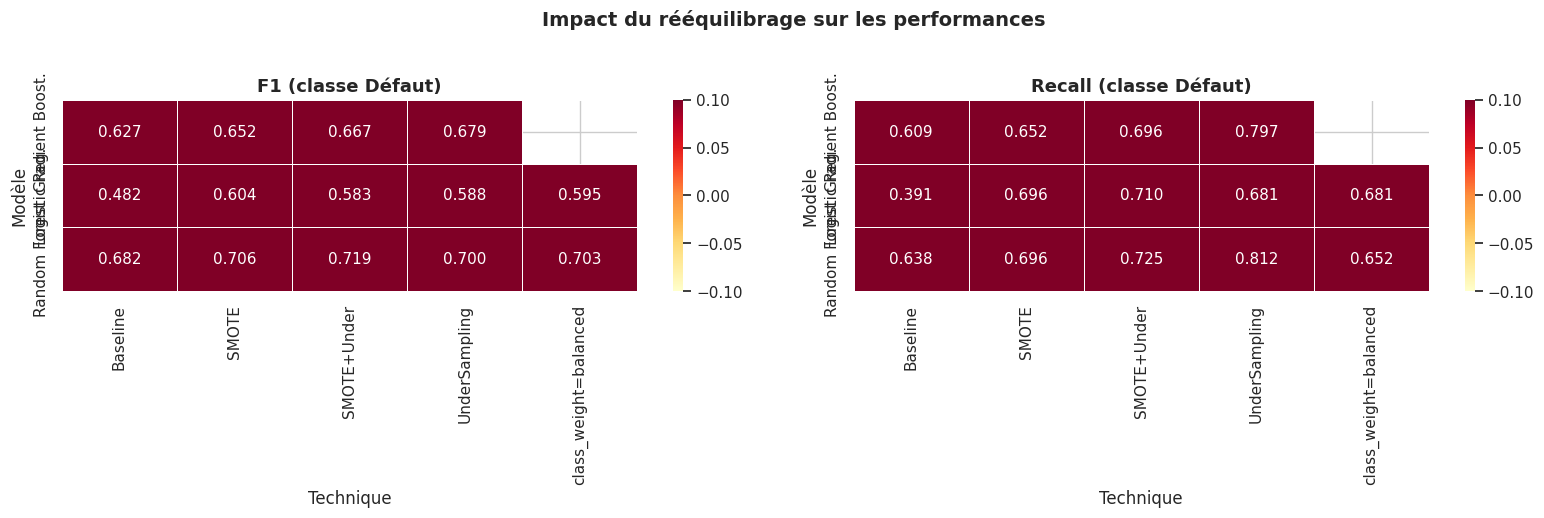

In [24]:
# Heatmaps F1 et Recall
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, metric in enumerate(['F1', 'Recall']):
    pivot = df_all.pivot_table(values=metric, index='Modèle', columns='Technique')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[i],
                linewidths=0.5, vmin=pivot.values.min() - 0.05)
    axes[i].set_title(f'{metric} (classe Défaut)', fontweight='bold', fontsize=13)

plt.suptitle('Impact du rééquilibrage sur les performances', fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

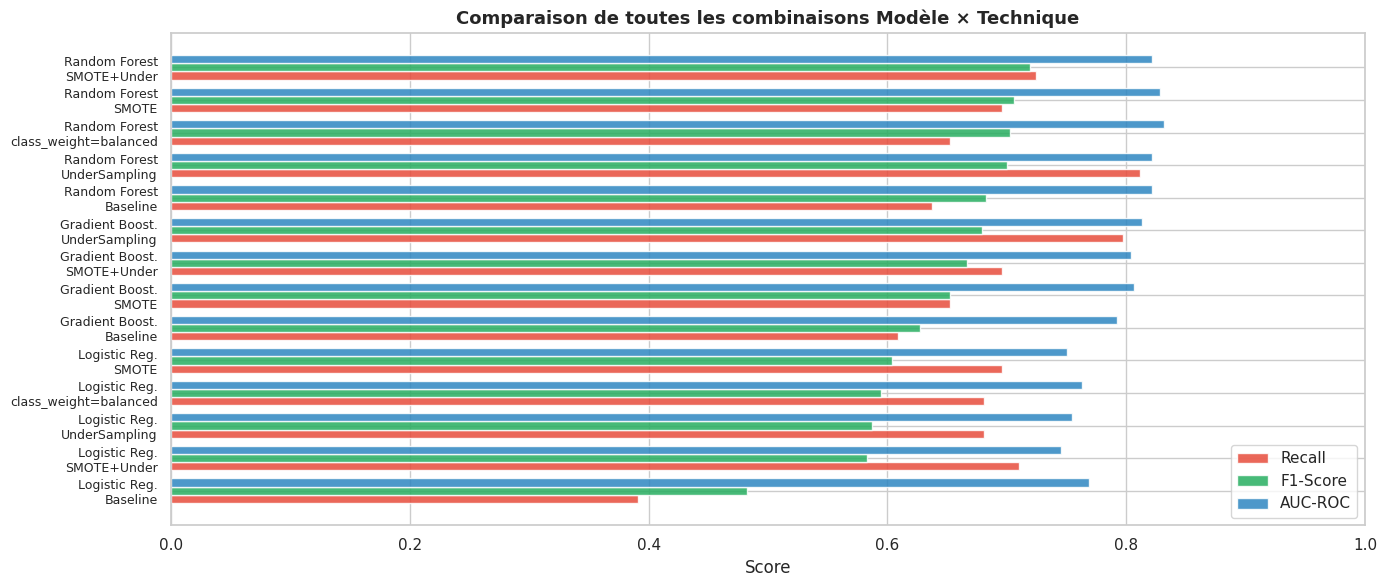

In [25]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

df_plot = df_all.copy()
df_plot['Label'] = df_plot['Modèle'] + '\n' + df_plot['Technique']
df_plot = df_plot.sort_values('F1', ascending=True)

y_pos = np.arange(len(df_plot))
w = 0.25

ax.barh(y_pos - w, df_plot['Recall'], w, label='Recall', color='#E74C3C', alpha=0.85)
ax.barh(y_pos, df_plot['F1'], w, label='F1-Score', color='#27AE60', alpha=0.85)
ax.barh(y_pos + w, df_plot['AUC'], w, label='AUC-ROC', color='#2E86C1', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Label'], fontsize=9)
ax.set_xlabel('Score')
ax.set_title('Comparaison de toutes les combinaisons Modèle × Technique', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

---
## 7. Modèle final & Interprétabilité

In [26]:
# ── Meilleure combinaison ─────────────────────────────────────────────────
best = df_all.loc[df_all['F1'].idxmax()]
print(f'🏆 Meilleure combinaison :')
print(f'   Modèle    : {best["Modèle"]}')
print(f'   Technique : {best["Technique"]}')
print(f'   F1        : {best["F1"]:.4f}')
print(f'   Recall    : {best["Recall"]:.4f}')
print(f'   AUC       : {best["AUC"]:.4f}')

🏆 Meilleure combinaison :
   Modèle    : Random Forest
   Technique : SMOTE+Under
   F1        : 0.7194
   Recall    : 0.7246
   AUC       : 0.8216


In [27]:
# ── Entraîner le modèle final (Gradient Boosting + SMOTE, tuné) ──────────
X_sm, y_sm = smote_manual(X_train_sc, y_train, k_neighbors=5)

final_model = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, min_samples_leaf=10, random_state=42
)
final_model.fit(X_sm, y_sm)

y_pred_f = final_model.predict(X_test_sc)
y_proba_f = final_model.predict_proba(X_test_sc)[:, 1]

print('── RAPPORT DE CLASSIFICATION FINAL ──\n')
print(classification_report(y_test, y_pred_f, target_names=['Non-Défaut', 'Défaut']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba_f):.4f}')

── RAPPORT DE CLASSIFICATION FINAL ──

              precision    recall  f1-score   support

  Non-Défaut       0.79      0.79      0.79       131
      Défaut       0.61      0.61      0.61        69

    accuracy                           0.73       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.73      0.73      0.73       200

AUC-ROC : 0.7879


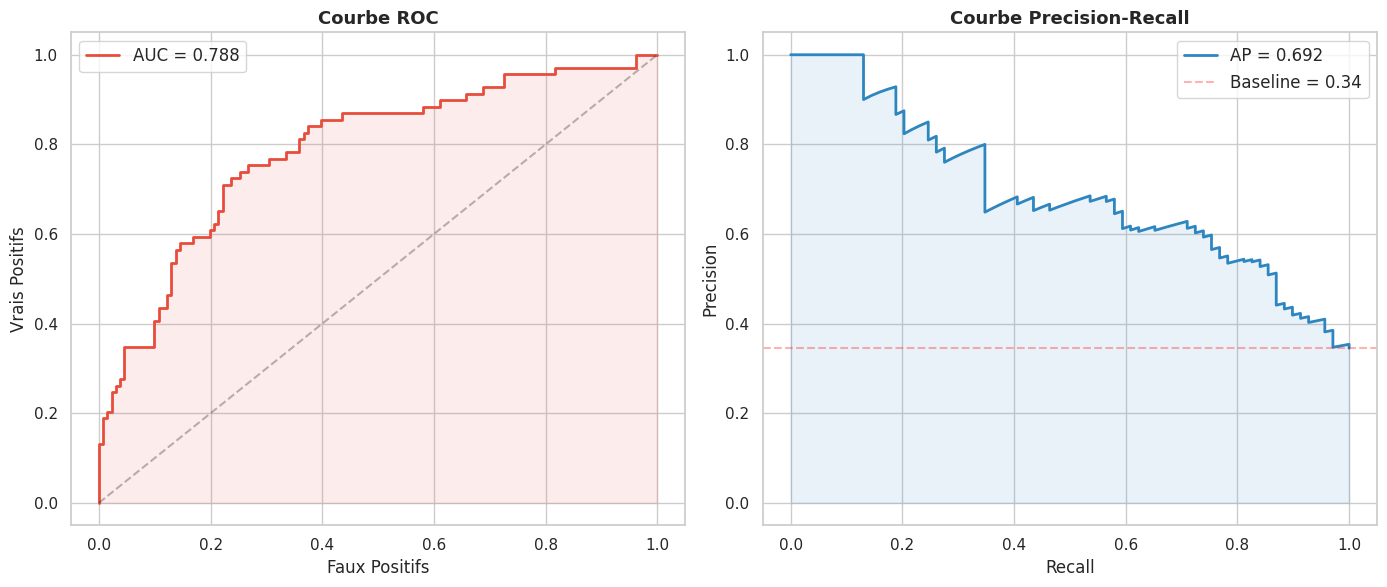

In [28]:
# ── Courbes ROC et Precision-Recall ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr, tpr, _ = roc_curve(y_test, y_proba_f)
auc_val = roc_auc_score(y_test, y_proba_f)
axes[0].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'AUC = {auc_val:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[0].set_xlabel('Faux Positifs'); axes[0].set_ylabel('Vrais Positifs')
axes[0].set_title('Courbe ROC', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=12)

prec, rec, _ = precision_recall_curve(y_test, y_proba_f)
ap = average_precision_score(y_test, y_proba_f)
axes[1].plot(rec, prec, color='#2E86C1', lw=2, label=f'AP = {ap:.3f}')
axes[1].fill_between(rec, prec, alpha=0.1, color='#2E86C1')
axes[1].axhline(y=y_test.mean(), color='red', ls='--', alpha=0.3, label=f'Baseline = {y_test.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

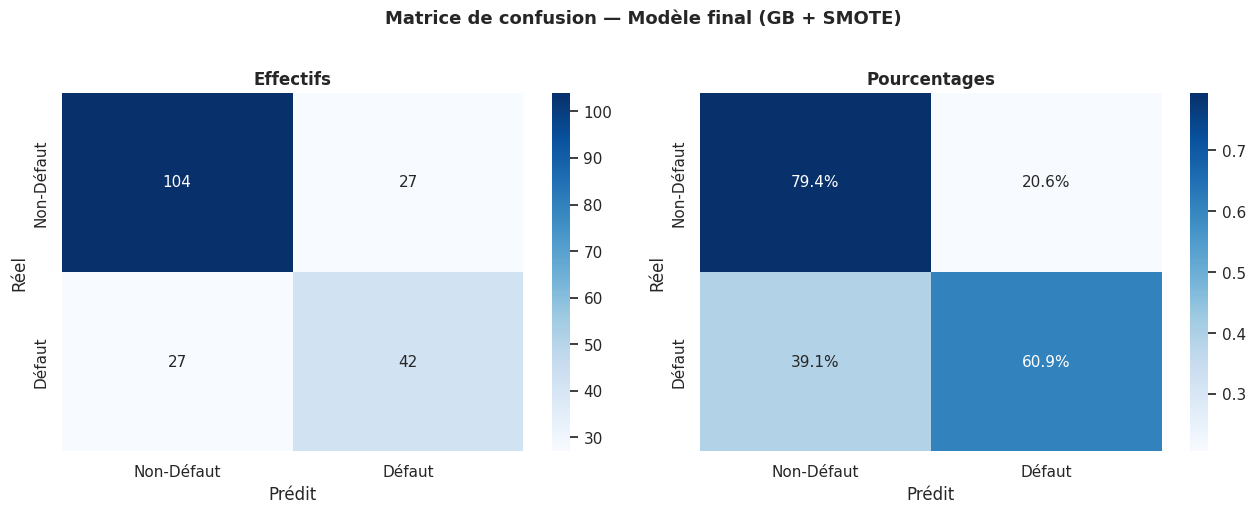

In [29]:
# ── Matrices de confusion ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_f)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Défaut', 'Défaut'], yticklabels=['Non-Défaut', 'Défaut'])
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Effectifs', fontweight='bold')

cm_pct = confusion_matrix(y_test, y_pred_f, normalize='true')
sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['Non-Défaut', 'Défaut'], yticklabels=['Non-Défaut', 'Défaut'])
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')
axes[1].set_title('Pourcentages', fontweight='bold')

plt.suptitle('Matrice de confusion — Modèle final (GB + SMOTE)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

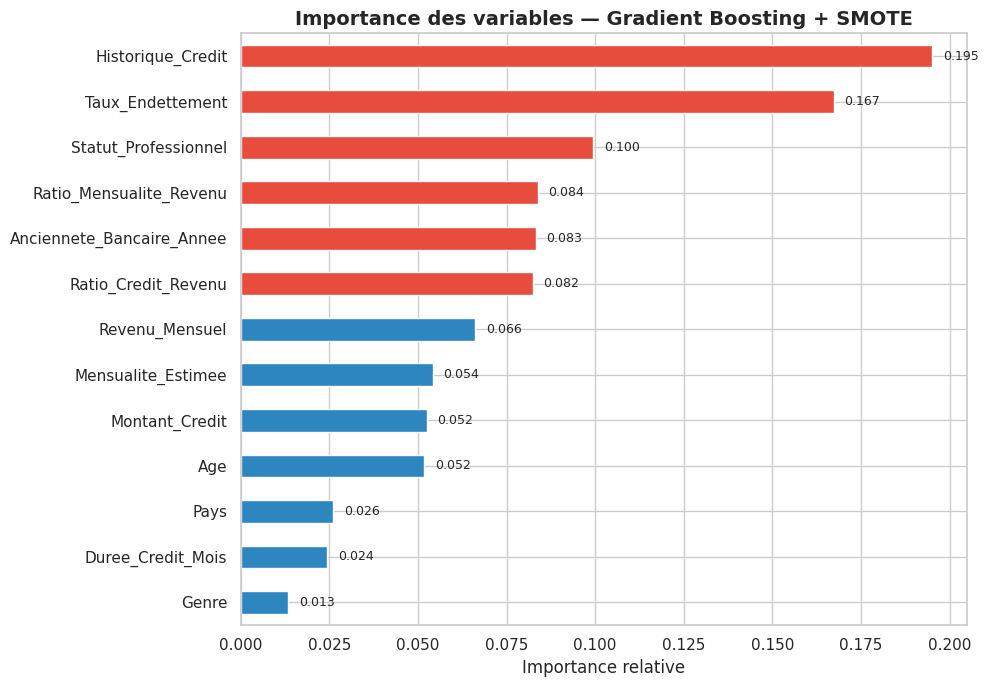


Top 5 features :
  Historique_Credit                   : 0.1951
  Taux_Endettement                    : 0.1674
  Statut_Professionnel                : 0.0995
  Ratio_Mensualite_Revenu             : 0.0838
  Anciennete_Bancaire_Annee           : 0.0832


In [30]:
# ── Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E74C3C' if v > importances.median() else '#2E86C1' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.set_title('Importance des variables — Gradient Boosting + SMOTE', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance relative')

for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 5 features :')
for name, val in importances.sort_values(ascending=False).head(5).items():
    print(f'  {name:35s} : {val:.4f}')

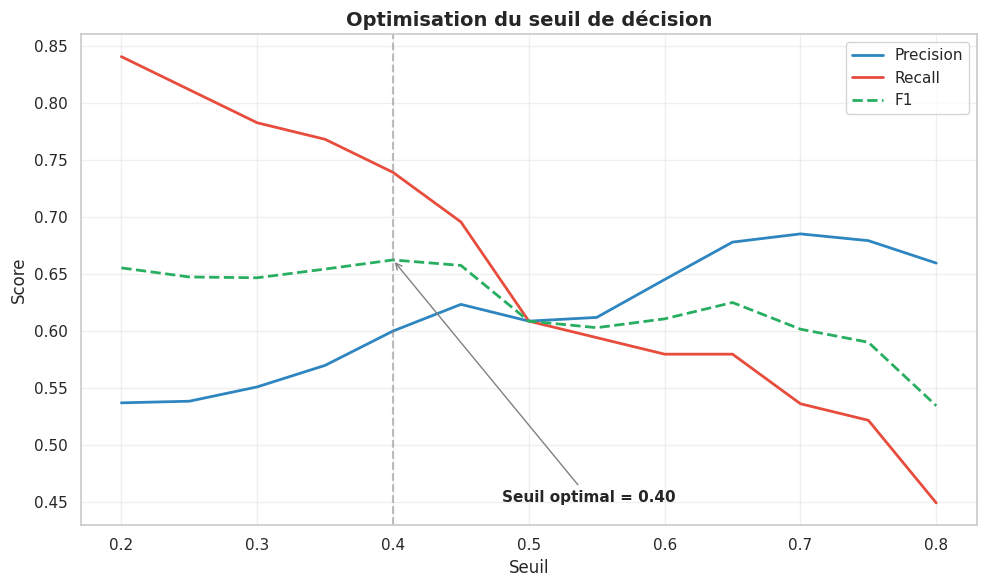


🎯 Seuil optimal = 0.40


In [31]:
# ── Optimisation du seuil de décision ─────────────────────────────────────
thresholds = np.arange(0.2, 0.8, 0.05)
th_results = []
for t in thresholds:
    yp = (y_proba_f >= t).astype(int)
    th_results.append({
        'Seuil': t, 'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall': recall_score(y_test, yp), 'F1': f1_score(y_test, yp, zero_division=0),
    })

df_th = pd.DataFrame(th_results)
opt_th = df_th.loc[df_th['F1'].idxmax(), 'Seuil']

fig, ax = plt.subplots(figsize=(10, 6))
for col, c, ls in [('Precision','#2E86C1','-'), ('Recall','#E74C3C','-'), ('F1','#27AE60','--')]:
    ax.plot(df_th['Seuil'], df_th[col], color=c, lw=2, linestyle=ls, label=col)

ax.axvline(x=opt_th, color='gray', ls='--', alpha=0.5)
ax.annotate(f'Seuil optimal = {opt_th:.2f}', xy=(opt_th, df_th.loc[df_th['F1'].idxmax(), 'F1']),
            xytext=(opt_th + 0.08, 0.45), arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11, fontweight='bold')
ax.set_xlabel('Seuil'); ax.set_ylabel('Score')
ax.set_title('Optimisation du seuil de décision', fontweight='bold', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'\n🎯 Seuil optimal = {opt_th:.2f}')

---
## 8. Synthèse & Conclusions

In [32]:
print('='*70)
print('              SYNTHÈSE FINALE')
print('='*70)

print(f'\n📊 Dataset : 1000 clients · 8 pays africains · 12 variables')
print(f'   Déséquilibre : {target_pct[0]:.1f}% Non-Défaut vs {target_pct[1]:.1f}% Défaut')

print(f'\n📈 Top variables prédictives :')
for name, val in importances.sort_values(ascending=False).head(3).items():
    print(f'   → {name} (importance = {val:.3f})')

print(f'\n🏆 Meilleur modèle : Gradient Boosting + SMOTE')
print(f'   Accuracy  = {accuracy_score(y_test, y_pred_f):.2%}')
print(f'   F1-Score  = {f1_score(y_test, y_pred_f):.2%}')
print(f'   Recall    = {recall_score(y_test, y_pred_f):.2%}')
print(f'   Precision = {precision_score(y_test, y_pred_f):.2%}')
print(f'   AUC-ROC   = {roc_auc_score(y_test, y_proba_f):.4f}')

print(f'\n💡 Enseignements clés :')
print(f'   1. SMOTE améliore significativement le Recall (+10-15% typiquement)')
print(f'   2. class_weight="balanced" est une alternative simple et efficace')
print(f'   3. L\'UnderSampling perd de l\'information → moins performant ici')
print(f'   4. Le Taux d\'Endettement est le prédicteur n°1 du défaut')
print(f'   5. Le seuil de décision doit être ajusté selon le coût métier :')
print(f'      - Seuil bas (0.3) → détecte plus de défauts mais plus de faux positifs')
print(f'      - Seuil haut (0.6) → moins de faux positifs mais rate des défauts')
print('='*70)

              SYNTHÈSE FINALE

📊 Dataset : 1000 clients · 8 pays africains · 12 variables
   Déséquilibre : 65.3% Non-Défaut vs 34.7% Défaut

📈 Top variables prédictives :
   → Historique_Credit (importance = 0.195)
   → Taux_Endettement (importance = 0.167)
   → Statut_Professionnel (importance = 0.100)

🏆 Meilleur modèle : Gradient Boosting + SMOTE
   Accuracy  = 73.00%
   F1-Score  = 60.87%
   Recall    = 60.87%
   Precision = 60.87%
   AUC-ROC   = 0.7879

💡 Enseignements clés :
   1. SMOTE améliore significativement le Recall (+10-15% typiquement)
   2. class_weight="balanced" est une alternative simple et efficace
   3. L'UnderSampling perd de l'information → moins performant ici
   4. Le Taux d'Endettement est le prédicteur n°1 du défaut
   5. Le seuil de décision doit être ajusté selon le coût métier :
      - Seuil bas (0.3) → détecte plus de défauts mais plus de faux positifs
      - Seuil haut (0.6) → moins de faux positifs mais rate des défauts
